In [19]:
import matplotlib.pyplot as plt
import numpy as np

from scipy.sparse import diags

In [10]:
import sys
import os

ROOT = os.path.abspath("..")
sys.path.append(ROOT)

from src.oracles import *
from src.optimization import *
from src.plot_trajectory_2d import *

In [22]:
def gen_func(n: int, k: float) -> QuadraticOracle:
    if n == 1:
        raise RuntimeError('n at least 2')
    eigen_values = np.array([1, k])
    if n > 2:
        eigen_values = np.concatenate((eigen_values, np.random.uniform(1, k, size=n-2)))
    A = diags(eigen_values)
    b = np.random.normal(0, 1, size=n)
    return QuadraticOracle(A, b)


def test_several_times(n: int, k_low: float, k_high: float, test_amount: int, max_iter=10000) -> list[(int, float)]:
    k_s = np.logspace(k_low, k_high, test_amount)
    results = []
    for k in k_s:
        oracle = gen_func(n, k)
        x_0, result, history = gradient_descent(
            oracle, np.zeros(n), trace=True, tolerance=1e-10, max_iter=max_iter)
        results.append((len(history['func']) - 1, k))
    return results

In [23]:
repeat_amount = 5
min_k = 0
max_k = 3
k_iters = 9

In [24]:
global_test_cases = [
    ('green', 10**1),
    ('red', 10**2),
    ('blue', 10**3),
    ('purple', 10**4),
]

In [25]:
data = []

In [26]:
for color, n in global_test_cases:
    data.append([])
    for i in range(repeat_amount):
        data[-1].append(test_several_times(n, min_k, max_k, k_iters, max_iter=5000))
        print(f'{n}, {i}')

10, 0
10, 1
10, 2
10, 3
10, 4
100, 0
100, 1
100, 2
100, 3
100, 4
1000, 0
1000, 1
1000, 2
1000, 3
1000, 4
10000, 0
10000, 1
10000, 2
10000, 3
10000, 4


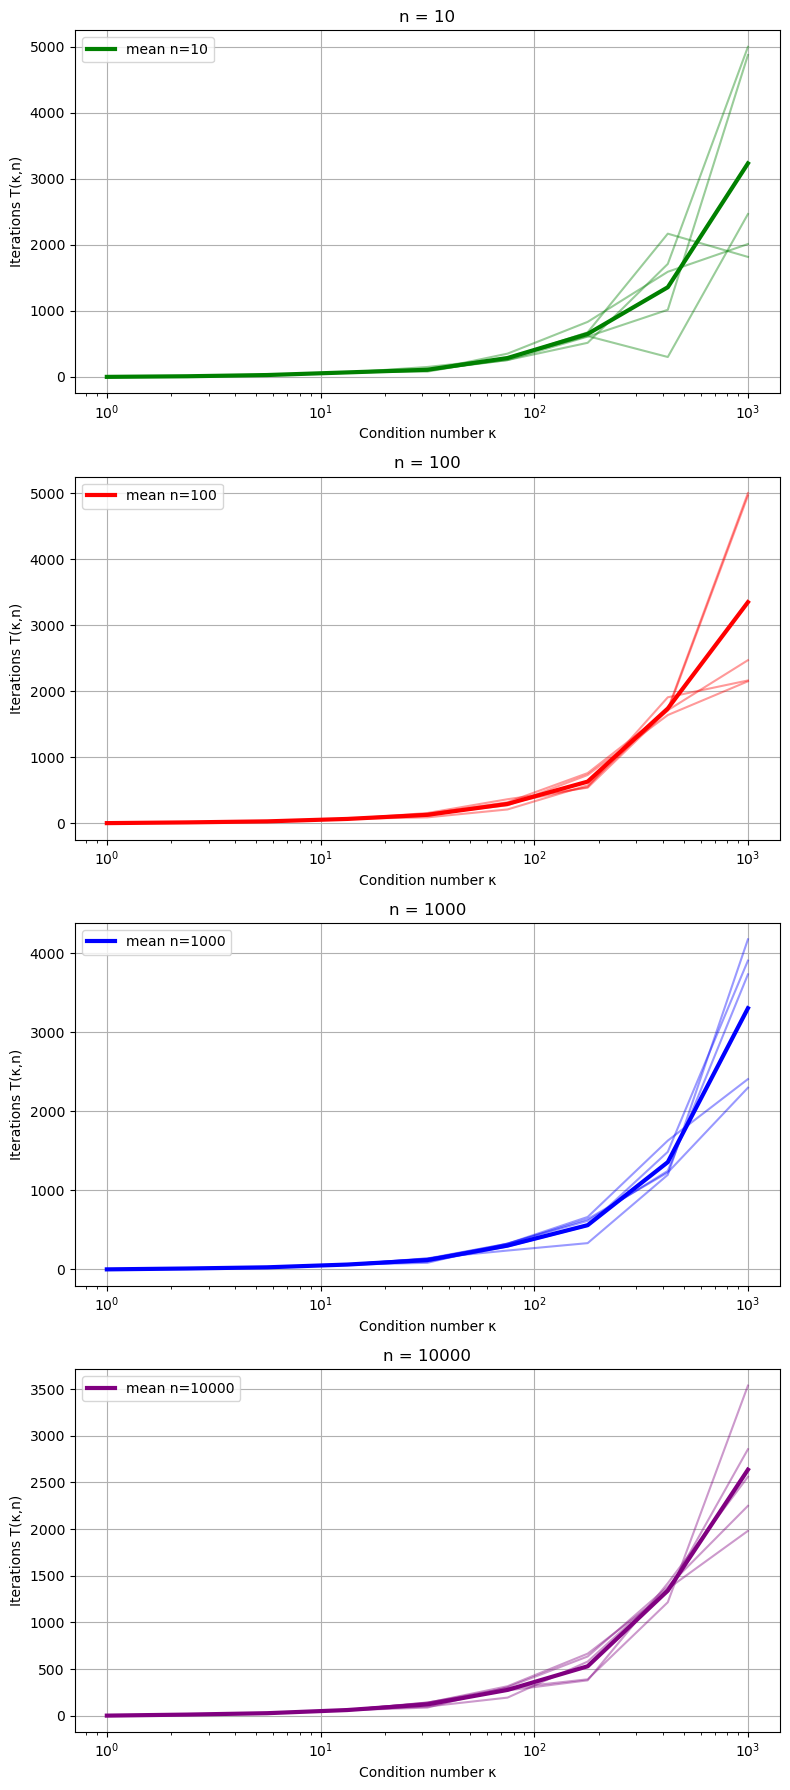

In [27]:
fig, axes = plt.subplots(len(global_test_cases), 1, figsize=(8, 18))

for ax, ((color, n), runs) in zip(axes, zip(global_test_cases, data)):

    all_iters = []

    for run in runs:
        ks = [k for t, k in run]
        iters = [t for t, k in run]

        all_iters.append(iters)

        ax.semilogx(ks, iters, color=color, alpha=0.4)

    mean_iters = np.mean(all_iters, axis=0)
    ax.semilogx(ks, mean_iters, color=color, linewidth=3, label=f"mean n={n}")

    ax.set_title(f"n = {n}")
    ax.set_xlabel("Condition number κ")
    ax.set_ylabel("Iterations T(κ,n)")
    ax.grid(True)
    ax.legend()
    if n == 10000:
        plt.savefig(f"../figs/task3/n_{n}.png")

plt.tight_layout()
plt.show()

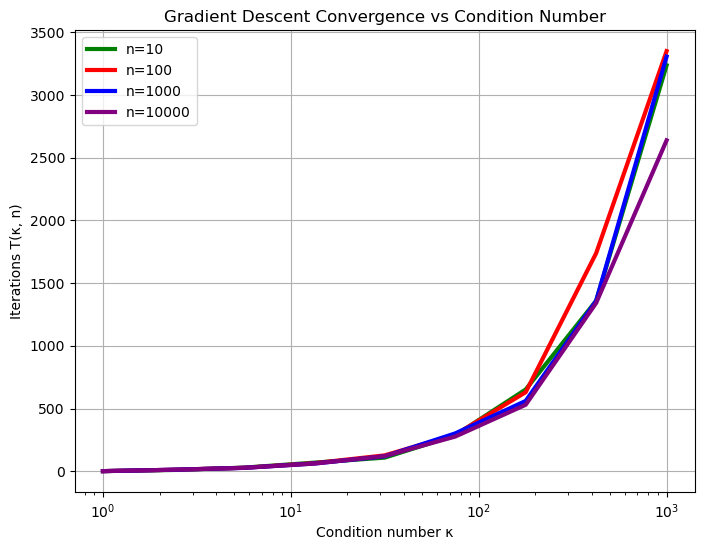

In [28]:
plt.figure(figsize=(8,6))

for (color, n), runs in zip(global_test_cases, data):

    all_iters = []

    for run in runs:
        ks = [k for _, k in run]
        iters = [t for t, _ in run]
        all_iters.append(iters)

    mean_iters = np.mean(all_iters, axis=0)

    plt.semilogx(ks, mean_iters, color=color, linewidth=3, label=f"n={n}")

plt.xlabel("Condition number κ")
plt.ylabel("Iterations T(κ, n)")
plt.title("Gradient Descent Convergence vs Condition Number")

plt.grid(True)
plt.legend()

plt.savefig("../figs/task3/all.png")
plt.show()